In [4]:
# Importing the required libraries
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt
from google.colab import files

In [5]:
# Uploading and reading the dataset
uploaded=files.upload()
df=pd.read_excel(next(iter(uploaded)))
# displaying the first few rows
print(df.head())
# checking the size of the dataset
print("\nDataset Shape:",df.shape)
# checking for missing values (if any because we need to do data preprocessing to trin ML)
print("\nMissing Values:")
print(df.isnull().sum())

Saving ex6third.xlsx to ex6third.xlsx
  Purchasing behaviour  Gender  Age  Time spent in online shop
0              Buy now  female   22                         40
1              Buy now  female   25                         23
2              Buy now    male   18                         12
3              Buy now    male   45                         28
4              Buy now  female   12                         43

Dataset Shape: (24, 4)

Missing Values:
Purchasing behaviour         0
Gender                       0
Age                          0
Time spent in online shop    0
dtype: int64


Selecting input features and splitting dataset

In [6]:
df["Gender"]=df["Gender"].map({"male":1,"female":0})

# Selecting the input features and target variable
X=df[["Gender","Age","Time spent in online shop"]]
y=df["Purchasing behaviour"]

# Splitting the dataset into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42
)

The Logistic Regression model is created and trained using the training data. then predicts the purchasing behaviour for the test dataset.

In [7]:
# Creating the Logistic Regression model
model=LogisticRegression(max_iter=1000)

# Training the model
model.fit(X_train,y_train)

# Predicting the test data
y_pred=model.predict(X_test)

# Displaying the predicted values
print("\nPredicted Values:")
print(y_pred)


Predicted Values:
['Buy now' 'Buy now' 'Buy now' "Don't buy anything" 'Buy now']



Accuracy Score: 0.4
Accuracy Percentage: 40.0 %

Confusion Matrix:
[[0 2 0]
 [0 1 0]
 [0 1 1]]


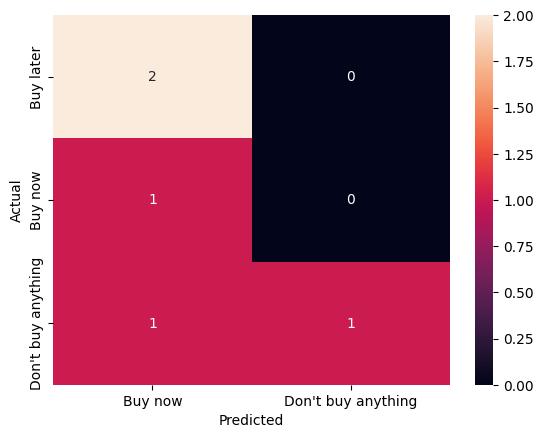

In [8]:
# Calculating the accuracy
acc=metrics.accuracy_score(y_test,y_pred)

print("\nAccuracy Score:",acc)
print("Accuracy Percentage:",round(acc*100,2),"%")

# Displaying the confusion matrix
conf_mat=metrics.confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:")
print(conf_mat)
conf_df=pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)
sn.heatmap(conf_df,annot=True)

plt.show()

The model is now evaluated using the Accuracy score and confusion matrix to measure its prediction performance.

Finally, the trained model predicts the purchasing behaviour of a new customer based on the given input values.

In [9]:
# Predicting for a new customer
new_customer=pd.DataFrame({"Gender":[1],"Age":[30],"Time spent in online shop":[35]})
prediction=model.predict(new_customer)
print("\nPrediction for New Customer:")
print(prediction[0])


Prediction for New Customer:
Buy now
